✅ Accuracy: 82.95%

               precision    recall  f1-score   support

           0       0.85      0.98      0.91      1686
           1       0.25      0.04      0.07       314

    accuracy                           0.83      2000
   macro avg       0.55      0.51      0.49      2000
weighted avg       0.75      0.83      0.77      2000



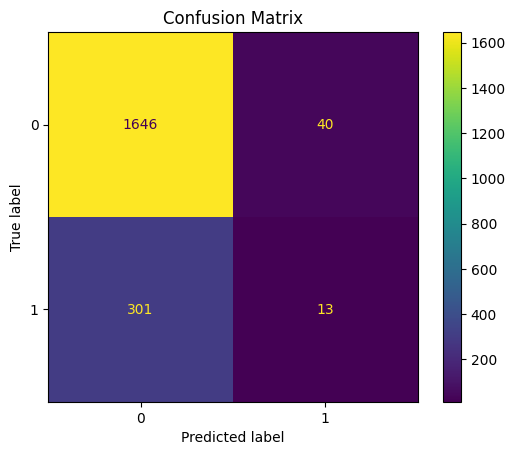

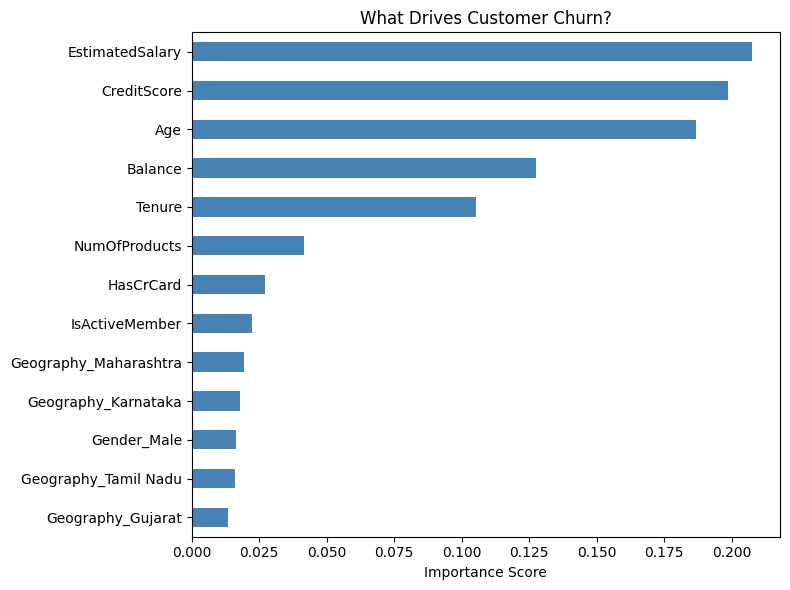

✅ Model Complete!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load & prepare
df = pd.read_csv('../data/Churn_Modelling.csv')
df = df.drop(['RowNumber','CustomerId','Surname','FirstName'], axis=1)
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)
X = df.drop('Exited', axis=1)
y = df['Exited']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n", classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

# Feature Importance ⭐
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='steelblue', figsize=(8,6))
plt.title("What Drives Customer Churn?")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("✅ Model Complete!")